In [44]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import cv2
# import the necessary packages
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# from keras.models import Sequential
# from keras.layers import Dense
from sklearn.preprocessing import StandardScaler
# from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import time
from math import sqrt
from sklearn.metrics.pairwise import cosine_distances

from plot_keras_history import show_history, plot_history

def get_encoding(series):
    #getting our classes
    array = series.to_numpy().reshape(-1,1)
    encoder = OneHotEncoder().fit(array)
    return encoder.transform(array).toarray(), encoder

def setup_keras_model(model, layers):
    for layer in layers:
        model.add(layer)
    
    print(model.summary())


def rmse(x,y):
    return sqrt(mean_squared_error(x,y))

    
def update_metrics(metric_df,df_test, preds, targets_str, metrics, model_name, input_features=None, epochs=10):    
    
    metric_df.loc[model_name, "input_features"] = input_features
    human_rows = df_test["class"] == "Pedestrian"
    metric_df.loc[model_name, "epochs"] = epochs
    hdf = df_test[human_rows]
    human_preds = [pred[human_rows] for pred in preds]
    
    #evaluate the targets
    for i, s in enumerate(targets_str):
        target = df_test[s]
        
        print(metrics[i](preds[i], target))
        metric = metrics[i](preds[i], target)
        metric_df.loc[model_name, f"{s}_{metrics[i].__name__}_total"] = metric
        
        #predict error for human targets only
        target = hdf[s]
        metric = metrics[i](human_preds[i], target)
        metric_df.loc[model_name, f"{s}_{metrics[i].__name__}_human"] = metric  
    

def save_model(model, model_dir, model_name):
    model_json = model.to_json()
    with open(f"{model_dir}/{model_name}.json", "w") as json_file:
        json_file.write(model_json)

    model.save_weights(f"{model_dir}/{model_name}.h5")
    print("Saved model to disk")

def aggregate_cos_distance(pred, target, aggregator=np.mean):
    return aggregator(np.matrix.diagonal(cosine_distances(pred, target)))

# update_metrics(metric_df, df_test["dist_feet"], df_test, "foo")

In [3]:
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)


gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
#set up some directory names
global_dirname = "/home/jack/Desktop/code/projects/deloitte/cv_distance_estimation"
data_dir = f"{global_dirname}/data"
img_dir = f"/home/jack/Desktop/code/projects/deloitte/cv_distance_estimation/data/training/image_2_bounding/"
subimage_pos_dir = f"{data_dir}/training/subimages_padded_w_position"
subimage_no_pos_dir = f"{data_dir}/training/subimages_padded_no_position"

subimage_dir = f"{data_dir}/training/subimages"

model_dir = f"{global_dirname}/models/"

#load data
df = pd.read_csv(f"{data_dir}/labels.csv")

df_train, df_test = (pd.read_csv(f"{data_dir}/train.csv"), pd.read_csv(f"{data_dir}/test.csv"))

df_train.reset_index(inplace=True)
df_test.reset_index(inplace=True)

img_metric_df = pd.DataFrame()

metric_df = pd.read_csv(f"{data_dir}/metrics/metric_df_bb_only.csv", index_col=0)

In [5]:
#choosing how many rows to train with
# n = 300
n = df_train.shape[0]

df_train = df_train.head(n)
df_test = df_test.head(n)

epochs = 50
verbose = 2
batch_size = 10

# train_class, class_encoder = get_encoding(df_train["class"])
train_class, class_encoder = get_encoding(df_train["class"])
test_class, class_encoder = get_encoding(df_test["class"])

class_shape_train = train_class[0].shape
class_shape_test = test_class[0].shape



#angle output encodings
# train_angle = get_encoding(df_train.angle_discrete)[0]
train_angle, angle_encoder = get_encoding(df_train.angle_discrete)
test_angle, class_encoder = get_encoding(df_test.angle_discrete)

angle_shape_train = train_angle[0].shape
angle_shape_test = test_angle[0].shape

angle_shape = train_class[0].shape


print(class_shape_train, class_shape_test)
print(angle_shape_train, angle_shape_test)

(8,) (8,)
(8,) (8,)


In [6]:
#setting up image directroy where the images will be coming from
file = f"{img_dir}/0.png"

image_shape = cv2.imread(file).shape

#subimage_shape with position
file = f"{subimage_pos_dir}/0.png"
subimage_pos_shape = cv2.imread(file).shape

#subimage shape without position
file = f"{subimage_no_pos_dir}/0.png"
subimage_no_pos_shape = cv2.imread(file).shape

In [7]:
class functional_api_generator(tf.keras.utils.Sequence):
  def __init__(self, df: pd.DataFrame, filenames: pd.Series, input_features: {str: [str],},
               output_features: {str: [str],}, batch_size: int, img_dir: str):
    self.df = df
    #encoders
    self.encoders = {}
    
    self.input_features = self.parse_features(input_features)
    self.output_features = self.parse_features(output_features)
    
    
        
    #filenames
    self.image_filenames = filenames
    
    #miscelaneous
    self.batch_size = batch_size
    self.img_dir = img_dir
    


    
  def __len__(self):
    return (np.ceil(len(self.image_filenames) / float(self.batch_size))).astype(int)
  
  
  def __getitem__(self, idx):
    

    start = idx * self.batch_size
    stop = (idx+1) * self.batch_size

    
    input_batch = {key: value[start:stop] for key, value in self.input_features.items()}
    output_batch = {key: value[start:stop] for key, value in self.output_features.items()}
    
    
    input_batch["img"] = np.array([cv2.imread(img_dir + str(file_name)) 
                                    for file_name in self.image_filenames[start:stop]])
    return input_batch, output_batch

  def parse_series(self, series):
    return get_encoding(series)[0] if series.dtype == object else series.values.reshape(-1,1)

  def parse_dataframe(self, df):
    values = []
    for key in df.columns:
        series = self.parse_series(df[key])
        values.append(series)
    
    return np.hstack(values)
    


  def parse_features(self, features):     
    features_w_data = {}
    for layer_key, df_key in features.items():
        data = self.df[df_key]
        
        if isinstance(data, pd.DataFrame):
            features_w_data[layer_key] = self.parse_dataframe(data)
                        
        elif isinstance(data, pd.Series):
            features_w_data[layer_key] = self.parse_series(data)
    
        
    return features_w_data

In [8]:
input_features_subimage = {"class": ["class"], "position": ["xmin", "xmax", "ymin","ymax"]}
output_features_angle_trig = {"distance": ["dist_feet"], "trig_angle": ["sin_angle", "cos_angle"]}

train_subimage_trig_generator = functional_api_generator(df_train, df_train["filename_bb"], input_features_subimage,
                                                 output_features_angle_trig, batch_size, subimage_dir)

test_subimage_trig_generator = functional_api_generator(df_test, df_test["filename_bb"], input_features_subimage,
                                                 output_features_angle_trig, batch_size, subimage_dir)

In [9]:
train_class, class_encoder = get_encoding(df_train["class"])
class_shape = test_class[0].shape

#angle output encodings
# train_angle = get_encoding(df_train.angle_discrete)[0]
test_angle, angle_encoder = get_encoding(df_train.angle_discrete)
angle_shape = test_angle[0].shape

#class input
class_input = keras.Input(shape=class_shape, name="class")

#subimage_input with relative input intact
subimage_rel_input = keras.Input(shape=subimage_pos_shape, name="img")

#subimage byitself
subimage_input = keras.Input(shape=(None,None,3), name="img")

#relative position
position_input = keras.Input(shape=(4,), name="position")

In [34]:
subimage_input = keras.Input(shape=(None,None,3), name="img")

subimage_input

#subimage no position
subimage_layer = keras.layers.Conv2D(500, kernel_size=3, activation="relu", padding="same")(subimage_input)
subimage_layer = keras.layers.GlobalAveragePooling2D()(subimage_layer)
# subimage_layer = keras.layers.Conv2D(250, kernel_size=3, activation="relu",padding="same")(subimage_layer)
# subimage_layer = keras.layers.GlobalAveragePooling2D()(subimage_layer)
subimage_layer = keras.layers.Flatten()(subimage_layer)


class_layer = keras.layers.Dense(30, kernel_initializer='normal', activation='relu')(class_input)
class_layer = keras.layers.Dense(15, kernel_initializer='normal', activation='relu')(class_layer)
class_layer = keras.layers.Dense(8, kernel_initializer='normal', activation='relu')(class_layer)


#position layers
position_layer = keras.layers.Dense(6, kernel_initializer='normal', activation='relu')(position_input)
position_layer = keras.layers.Dense(5, kernel_initializer='normal', activation='relu')(position_layer)
position_layer = keras.layers.Dense(2, kernel_initializer='normal', activation='relu')(position_layer)


# #concatanate the two layers
combined_layer = keras.layers.concatenate([subimage_layer, class_layer, position_layer])

# combined_layer = keras.layers.concatenate([subimage_layer, class_layer])


combined_layer = keras.layers.Dense(100, activation="relu")(combined_layer)
combined_layer = keras.layers.Dense(32, activation="relu")(combined_layer)

# #output layers
dist_layer = keras.layers.Dense(1, name="distance")(combined_layer)
angle_layer = keras.layers.Dense(2, name="trig_angle")(combined_layer)

In [35]:
subimage_model = keras.Model(
    inputs=[subimage_input, class_input, position_input],
    outputs=[dist_layer, angle_layer],
)
epochs=50

Epoch 1/50
3043/3043 - 143s - loss: 2539.9041 - distance_loss: 2540.0176 - trig_angle_loss: -1.1584e-01 - val_loss: 1797.2552 - val_distance_loss: 1797.3832 - val_trig_angle_loss: -1.3024e-01 - 143s/epoch - 47ms/step
Epoch 2/50
3043/3043 - 142s - loss: 1191.7264 - distance_loss: 1191.8751 - trig_angle_loss: -1.4762e-01 - val_loss: 892.9485 - val_distance_loss: 893.0804 - val_trig_angle_loss: -1.3179e-01 - 142s/epoch - 47ms/step
Epoch 3/50
3043/3043 - 141s - loss: 657.7224 - distance_loss: 657.8641 - trig_angle_loss: -1.4329e-01 - val_loss: 510.1111 - val_distance_loss: 510.2419 - val_trig_angle_loss: -1.3073e-01 - 141s/epoch - 46ms/step
Epoch 4/50
3043/3043 - 136s - loss: 402.3580 - distance_loss: 402.5031 - trig_angle_loss: -1.4468e-01 - val_loss: 326.0263 - val_distance_loss: 326.1577 - val_trig_angle_loss: -1.3144e-01 - 136s/epoch - 45ms/step
Epoch 5/50
3043/3043 - 135s - loss: 293.3827 - distance_loss: 293.5277 - trig_angle_loss: -1.4503e-01 - val_loss: 265.1324 - val_distance_loss

Epoch 40/50
3043/3043 - 140s - loss: 107.0132 - distance_loss: 107.1595 - trig_angle_loss: -1.4615e-01 - val_loss: 116.2984 - val_distance_loss: 116.4328 - val_trig_angle_loss: -1.3446e-01 - 140s/epoch - 46ms/step
Epoch 41/50
3043/3043 - 138s - loss: 105.9157 - distance_loss: 106.0617 - trig_angle_loss: -1.4616e-01 - val_loss: 114.4891 - val_distance_loss: 114.6241 - val_trig_angle_loss: -1.3491e-01 - 138s/epoch - 46ms/step
Epoch 42/50
3043/3043 - 143s - loss: 105.7420 - distance_loss: 105.8884 - trig_angle_loss: -1.4628e-01 - val_loss: 112.2553 - val_distance_loss: 112.3897 - val_trig_angle_loss: -1.3440e-01 - 143s/epoch - 47ms/step
Epoch 43/50
3043/3043 - 142s - loss: 104.8220 - distance_loss: 104.9681 - trig_angle_loss: -1.4610e-01 - val_loss: 112.4888 - val_distance_loss: 112.6236 - val_trig_angle_loss: -1.3484e-01 - 142s/epoch - 47ms/step
Epoch 44/50
3043/3043 - 143s - loss: 104.7708 - distance_loss: 104.9168 - trig_angle_loss: -1.4620e-01 - val_loss: 112.3623 - val_distance_loss:

(<Figure size 1080x360 with 3 Axes>,
 array([<AxesSubplot:title={'center':'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <AxesSubplot:title={'center':'Distance loss'}, xlabel='Epochs', ylabel='Distance loss'>,
        <AxesSubplot:title={'center':'Trig angle loss'}, xlabel='Epochs', ylabel='Trig angle loss'>],
       dtype=object))

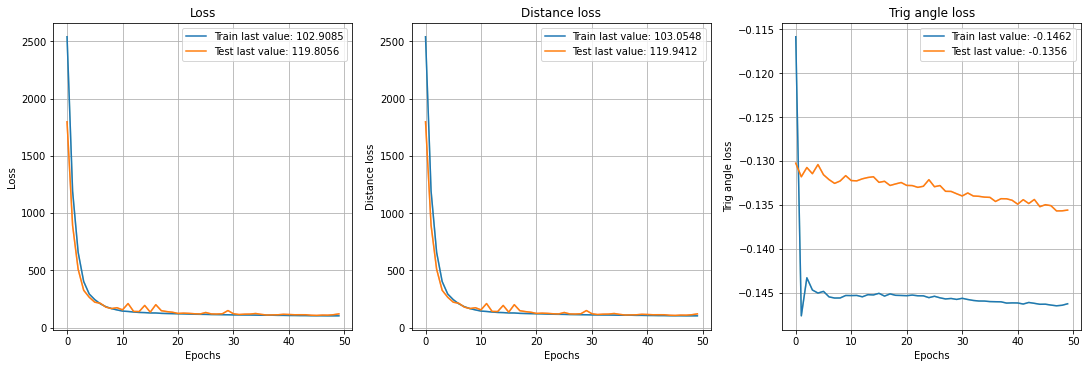

In [36]:
model_name = "subimage+class+position~dist_feet"

keras.utils.plot_model(subimage_model, f"{global_dirname}/models/diagrams/{model_name}.png", show_shapes=True)



subimage_model.compile(loss={"distance": "mean_squared_error", "trig_angle": "cosine_similarity"},
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, decay=0.00001))

subimage_model_history = subimage_model.fit(train_subimage_trig_generator,
                    validation_data = test_subimage_trig_generator, batch_size=32,epochs=epochs, verbose=2)



save_model(subimage_model, model_dir, model_name)
plot_history(subimage_model_history, path=f"{global_dirname}/results_history/{model_name}")

In [ ]:
dist_pred, trig_angle = subimage_model.predict(test_subimage_trig_generator)


update_metrics(img_metric_df, df_test, 
               (dist_pred, trig_angle),
               ("dist_feet", ["cos_angle", "sin_angle"], ["xmin", "xmax", "ymin", "ymax"]),
               (rmse, aggregate_cos_distance),
               model_name,
              epochs=epochs)



img_metric_df.to_csv(f"{data_dir}/metrics/model_metrics.csv")

In [40]:
pred[1]


array([[-10.238355 , -11.785922 ],
       [ -8.374192 ,  -8.876944 ],
       [-12.409793 , -11.01285  ],
       ...,
       [-13.505539 , -12.12054  ],
       [ -6.1702633,  -9.416907 ],
       [-10.201608 , -10.979095 ]], dtype=float32)